In [19]:
from dotenv import load_dotenv
load_dotenv()

True

In [20]:
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from pydantic import BaseModel, Field

In [21]:
model = init_chat_model('gpt-5-nano')

In [22]:
class SupportState(TypedDict):
    query: str
    category: str
    response: str

In [23]:
class RouteDecision(BaseModel):
    category: Literal['billing','technical','shipping','general'] = Field(description="고객 문의관련 카테고리")

In [24]:
route_agent = model.with_structured_output(RouteDecision)

In [54]:
def router_node(state: SupportState):
    print('[route 실행]')
    query = state['query']
    response = route_agent.invoke(query)
    
    print(f'질문분류결과 : {response.category} 부서로 연결합니다.')
    return { 'category' : response.category }


In [55]:
def billing_node(state:SupportState):
    print('[Billing Exper] 결제관련 답변 작성중')
    prompt = f'당신은 결제 및 환불 전문가입니다. 다음 문의에 정중하게 답변해주세요.  문의 : {state['query']}'
    response = model.invoke(prompt)
    return {'response':response.content}

In [56]:
def technical_node(state:SupportState):
    print('[technical Exper] 기술지원 답변 작성중')
    prompt = f'당신은 기술지원 파트 전문가입니다. 다음 문의에 정중하게 답변해주세요.  문의 : {state['query']}'
    response = model.invoke(prompt)
    return {'response':response.content}

In [57]:
def shipping_node(state:SupportState):
    print('[Shipping Exper] 물류,배송 답변 작성중')
    prompt = f'당신은 배송 파트 관리자입니다. 다음 문의에 정중하게 답변해주세요.  문의 : {state['query']}'
    response = model.invoke(prompt)
    return {'response':response.content}

In [58]:
def general_node(state:SupportState):
    print('[General Exper] 일반 답변 작성중')
    prompt = f'당신은 일반문의 관련 상담사 입니다. 다음 문의에 정중하게 답변해주세요.  문의 : {state['query']}'
    response = model.invoke(prompt)
    return {'response':response.content}

In [59]:
graph_builder = StateGraph(SupportState)

graph_builder.add_node('router_node',router_node)
graph_builder.add_node('billing_node',billing_node)
graph_builder.add_node('technical_node',technical_node)
graph_builder.add_node('shipping_node',shipping_node)
graph_builder.add_node('general_node',general_node)

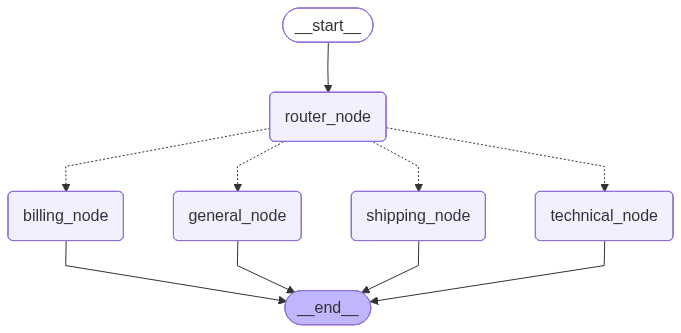

In [60]:
graph_builder.add_edge(START,'router_node')

def route_to_expert(state:SupportState):
    print(f'[ROUTE EXPERT]   :  {state['category']}')
    category = state['category']

    if category == 'billing':
        return 'billing_node'
    elif category == 'technical':
        return 'technical_node'
    elif category == 'shipping':
        return 'shipping_node'
    else:
        return 'general_node'
    

graph_builder.add_conditional_edges(
    'router_node',
    route_to_expert,
    {
        'billing_node' : 'billing_node',
        'technical_node' : 'technical_node',
        'shipping_node' : 'shipping_node',
        'general_node' : 'general_node'
    }
)


graph_builder.add_edge('billing_node', END)
graph_builder.add_edge('technical_node', END)
graph_builder.add_edge('shipping_node', END)
graph_builder.add_edge('general_node', END)

agent = graph_builder.compile()
agent




In [61]:
response = agent.invoke({'query':'최근 주문한 상품이 아직 배송이 안되었는데 왜 안되었을까요?'})
response

[route 실행]
질문분류결과 : shipping 부서로 연결합니다.
[ROUTE EXPERT]   :  shipping
[Shipping Exper] 물류,배송 답변 작성중


{'query': '최근 주문한 상품이 아직 배송이 안되었는데 왜 안되었을까요?',
 'category': 'shipping',
 'response': '다음과 같이 정중하게 답변하실 수 있습니다.\n\n안녕하세요. 문의 주셔서 감사합니다. 최근 주문하신 상품의 배송이 아직 도착하지 않아 불편을 드려 정말 죄송합니다.\n\n배송 지연의 일반적인 원인으로는 아래와 같은 경우가 있습니다.\n- 결제 확인 지연 또는 시스템 처리 문제\n- 재고 품절 및 재고 확정 중\n- 물류센터의 작업 지연, 택배사 이슈(날씨, 교통, 파업 등)\n- 수령지 주소나 연락처 누락/오류로 인한 재배송 필요\n- 국제 배송의 통관 지연 등\n\n정확한 현황 확인과 해결을 위해 아래 정보를 알려주시면 바로 조회 후 조치를 진행하겠습니다.\n- 주문번호\n- 수령인 성함\n- 배송지 주소\n- 연락 가능한 전화번호\n\n확인 즉시 배송 상태를 파악하고, 필요 시 재발송 또는 배송 일정 안내를 드리겠습니다. 추가로 원하시는 연락 방법(전화/이메일)도 함께 알려주시면 그 방법으로도 안내드리겠습니다. 다시 한 번 불편을 드려 죄송합니다. 신속히 해결해 드리겠습니다. 감사합니다.'}

In [76]:
#오케스트라 패턴
from typing import Annotated, TypedDict, List
from pydantic import BaseModel, Field
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage,SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

In [77]:
llm = init_chat_model(model = 'gpt-5-mini') 

In [78]:
import operator

class Task(BaseModel):
    name : str = Field(description="작업이름")
    role : str = Field(description='작업을 수행할 worker의 역활')
    instruction : str = Field(description='worker에게 전달할 구체적인 지시사항')

class TaskPlan(BaseModel):
    tasks : List[Task] = Field(description='worker에게 나누어줄 작업 목록')


class State(TypedDict):
    topic : str
    tasks : List[Task]
    completed_tasks: Annotated[List[str], operator.add]
    final_answer : str

In [79]:
class WorkerState(TypedDict):
    task : Task
    topic : str
    completed_tasks: Annotated[List[str], operator.add]


In [80]:
plan_llm = llm.with_structured_output(TaskPlan)

In [81]:
def orchestrator(state:State):
    print(['지휘 시작'])
    topic = state['topic']

    plan = plan_llm.invoke(
        [
            SystemMessage(content='''
                          당신은 AI교육프로그램 제안서를 설계하는 오케스트레이터입니다.

                          사용자의 주제를 분석해서 여러 Worker가 나눠서 처리할 작업 목록을 만드세요.

                          조건:
                          - 작업은 4개로 나누세요.
                          - 각 작업은 서로 독립적으로 수행 가능해야 합니다.
                          - 각 작업에는 name, role, instruction을 포함하세요.
                          - worker가 바로 실행할수 있을 정도로  instruction을 구체적으로 작성하세요
                          '''
                          ),

            HumanMessage(content=f'주제 : {topic}')

        ]
    )

    return {'tasks':plan.tasks}



def assign_workers(state:State):
    
    return [ 
        Send('worker' , { 'task' : task , 'topic':state['topic'], 'completed_task': []})  for task in state['tasks']
    ]


def worker(state: WorkerState):
    task = state['task']

    response = llm.invoke(
        [
            SystemMessage(content= f'''
                당신은 {task.role} 역활의 전문 worker입니다.

                규칙:
                - 오직 할당받은 작업만 수행하세요.
                - 다른 worker의 역할까지 절대 수행하시 마세요.
                - 제안서에 바로 넣을수 있는 결과물로 작성해주세요.
                - 한국어로 작성하세요.
                - 블릿과 소제목을 적절하게 사용하세요
            ''') , 
            HumanMessage( content = f'''
                전체주제 : {state['topic']}

                작업이름 : {task.name}

                작업지시사항 : {task.instruction}
            '''
            )

        ]
    )

    worker_result = f''' 
        ## {task.name}
        담당역할 :  {task.role}

        {response.content}
    '''

    return {'completed_tasks' : [worker_result]}
        



In [82]:
def synthesizer(state:State):
    worker_outputs = '\n\n'.join(state['completed_tasks'])

    response = llm.invoke(
        [
            SystemMessage(content='''
            당신은 전문 제안서 작성자입니다.
            여러  worker가 작성한 내용을 하나의 완성도 높은 교육 제안서 초안으로 통합하세요.

            조건:
            - 중복 내용은 제거하세요.
            - 자연스러운 문서 흐름으로 재구성하세요.
            - 제목, 개요, 교육목표, 주요내용, 실습구성, 운영방안, 기대효과를 포함하세요.
            - 한국어로 작성하세요.
            - 기관 제출용 문체로 작성하세요. 
             '''),
            HumanMessage(content=f'''  
            제안서 주제 : {state['topic']}

            worker 결과 :
            {worker_outputs}
            ''')

        ]
    )

    return {'final_answer' : response.content}

In [83]:
graph_builder = StateGraph(State)
graph_builder.add_node('orchestrator', orchestrator)
graph_builder.add_node('worker', worker)
graph_builder.add_node('synthesizer', synthesizer)

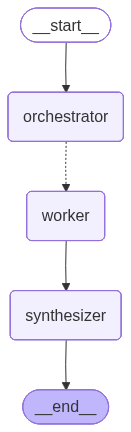

In [84]:
graph_builder.add_edge(START,'orchestrator')
graph_builder.add_conditional_edges(
    'orchestrator',
    assign_workers,
    ['worker']
)

graph_builder.add_edge('worker', 'synthesizer')
graph_builder.add_edge('synthesizer',END)

agent = graph_builder.compile()
agent


In [85]:
response = agent.invoke(
    {
        'topic' : '하네스엔지니어링을 활용한 대학생 창업교육 프로그램'
    }
)

print(response['final_answer'])

['지휘 시작']
제안서
과정명: 하네스엔지니어링을 활용한 대학생 창업교육 프로그램

1. 개요
본 프로그램은 하네스(케이블·커넥터·섬유 통합 설계) 엔지니어링을 중심으로 대학생의 하드웨어 설계·제작 역량과 창업 역량을 동시에 배양하고, 시제품 제작·검증에서 투자·제조 연계까지의 실무적 경험을 제공하기 위한 학기형 교육과정입니다. 표준 운영은 12주(학기)이며 주당 권장 학습시간은 이론 2시간·실습 3시간으로 총 60시간(이론 24h/실습 36h)을 기준으로 설계되었습니다. 대상은 공학·디자인·창업 관심 대학생(학부생·석사 포함)입니다.

2. 교육목표
1) 하네스 설계·제작 역량: 배선 하니스와 웨어러블 하우징을 포함한 하네스 설계·제작을 통해 기능적 프로토타입을 독립 또는 팀 단위로 구현한다.
2) 시스템 통합·검증 역량: 센서·임베디드·전원 통합 설계 및 안전·신뢰성·제조성을 고려한 검증을 수행한다.
3) 사업화 역량: 하네스 기반 제품의 시장성 분석과 비즈니스 모델 수립을 통해 투자유치용 피치 및 사업계획서를 제시한다.

3. 대상 및 선수지식
- 대상 전공: 전기/전자, 기계, 컴퓨터, 산업디자인·패션·텍스타일, 바이오의공학, 경영/창업 등 융합형 팀 권장
- 선수지식: 기초 전기회로(저항·전압·전류), 기초 프로그래밍(C/C++ 또는 Python), 기초 기구·재료 지식

4. 커리큘럼 개요(12주 요약)
주차별 핵심 주제(각 주 2h 이론 / 3h 실습 권장)
1주차: 하네스 개요·시장기회 — 정의·응용사례, 상용제품 분해 워크숍  
2주차: 인체공학·측정방법 — 착용성 설계·측정 실습  
3주차: 전원관리 — 전원요구 산출·배터리·BMS 실습  
4주차: 센서 개론(EMG/IMU/압력/스트레인) — 센서 인터페이스 실습  
5주차: 액추에이터·구동·안전 — 드라이버 제어 및 안전 실습  
6주차: 배선설계·커넥터 — 하네스 도면화·커넥터 선택·압착 실습  
7주차: 임베디드·PCB 통합 — MCU·통신·간이 PCB 통합 실습(중간데모 준비)  
